# Task 3.2 — Failure Mode Analysis (15 marks)

**Paper:** *Online Discovery and Maintenance of Time Series Motifs* — Mueen et al., KDD 2010

---

## Failure Scenario: Non-Stationary Amplitude (Structural Drift)

**Description of the failure scenario:**  
The algorithm assumes that z-normalisation (Assumption 2 from Task 1.2, Section 2) makes all subsequences comparable in terms of shape. However, in a stream where a signal's amplitude *gradually drifts* or has a sudden large spike, many segments from completely different parts of the stream will, after z-normalisation, look structurally similar — because z-normalisation stretches/compresses each subsequence to unit variance regardless of scale.

**Why we expect the method to struggle:**  
If the stream has two distinct regimes — a low-amplitude background regime and a high-amplitude spike regime — and within each regime there are internally similar (but regime-distinct) patterns, z-normalisation erases the regime distinction. The method may then report two subsequences from *different regimes* (e.g., a small noise bump and a large spike, both of which happen to be unimodal after normalisation) as the motif pair, even though they are structurally and semantically unrelated. The user would interpret this as a "repeated pattern" when in fact it is an artefact of normalisation flattening the magnitude axis.

This failure is directly connected to **Assumption 2** from Task 1.2: the assumption that z-normalised Euclidean distance faithfully reflects meaningful structural repetition. When the stream is non-stationary in amplitude, this assumption is violated.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pathlib

np.random.seed(42)

DATA_DIR    = pathlib.Path('data')
RESULTS_DIR = pathlib.Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

m, w = 20, 100

def z_normalise(subseq):
    mu, sigma = subseq.mean(), subseq.std()
    if sigma < 1e-8:
        return None
    return (subseq - mu) / sigma

def brute_force_motif(window_data, m):
    n_subseq = len(window_data) - m + 1
    subseqs = [z_normalise(window_data[i: i+m]) for i in range(n_subseq)]
    valid   = [s is not None for s in subseqs]
    best_i, best_j, best_dist = -1, -1, np.inf
    for i in range(n_subseq):
        if not valid[i]: continue
        for j in range(i + m, n_subseq):
            if not valid[j]: continue
            d = float(np.sqrt(np.sum((subseqs[i] - subseqs[j])**2)))
            if d < best_dist:
                best_dist = d; best_i, best_j = i, j
    return best_i, best_j, best_dist

print("Helpers loaded.")


Helpers loaded.


## Constructing the Failure-Inducing Stream

We build a stream of 500 points with:
- **Background**: low-amplitude Gaussian noise (σ=0.2)
- **True repeated pattern**: a 5 Hz sine burst at positions 50 and 200 (amplitude=0.8, same shape)
- **Adversarial spike pattern**: two large amplitude spikes at positions 350 and 430 (amplitude=5×) that look like the same unimodal bump after z-normalisation


In [2]:
# ─── Build the failure stream ─────────────────────────────────────────────────
np.random.seed(42)
N       = 500
failure_stream = np.random.normal(0, 0.2, N)  # low-amplitude noise background

# True repeated motif (amplitude 0.8)
t_m = np.linspace(0, 2*np.pi, m)
true_motif = 0.8 * np.sin(5 * t_m)
failure_stream[50: 50+m]  = true_motif.copy()
failure_stream[200: 200+m] = true_motif.copy()

# Adversarial high-amplitude spike (amplitude 5): a simple Gaussian bump
spike = 5.0 * np.exp(-0.5 * ((np.arange(m) - m/2) / 3)**2)
failure_stream[350: 350+m] = spike.copy()
failure_stream[430: 430+m] = spike.copy()

print("Failure stream summary:")
print(f"  True motif  : positions 50-69 and 200-219 (sine, amplitude 0.8)")
print(f"  Spike motif : positions 350-369 and 430-449 (Gaussian bump, amplitude 5.0)")
print(f"  Background  : Gaussian noise, sigma=0.2")

# Save for reference
np.save(DATA_DIR / 'failure_stream.npy', failure_stream)


Failure stream summary:
  True motif  : positions 50-69 and 200-219 (sine, amplitude 0.8)
  Spike motif : positions 350-369 and 430-449 (Gaussian bump, amplitude 5.0)
  Background  : Gaussian noise, sigma=0.2


In [3]:
# ─── Demonstrate the failure ──────────────────────────────────────────────────
# Brute-force on the final window, which contains BOTH the spike pair AND the true motif pair.
# We expect the algorithm to report the spike pair as the motif (they look identical
# after z-norm because they're both Gaussian bumps), even though the "intended" motif
# if we care about shape-at-scale would depend on the user's goal.

final_window = failure_stream[N-w:]
bf_i, bf_j, bf_dist = brute_force_motif(final_window, m)
global_off = N - w

print(f"Brute-force motif in final window :")
print(f"  Pair   : ({global_off + bf_i}, {global_off + bf_j})")
print(f"  Dist   : {bf_dist:.4f}")
print()

# Compare z-norms of the two spike subsequences and the true motif pair
def get_znorm_from_stream(stream, start, m):
    sub = stream[start: start+m]
    return z_normalise(sub)

z_spike1 = get_znorm_from_stream(failure_stream, 350, m)
z_spike2 = get_znorm_from_stream(failure_stream, 430, m)
z_true1  = get_znorm_from_stream(failure_stream, 50,  m)
z_true2  = get_znorm_from_stream(failure_stream, 200, m)

d_spikes = np.sqrt(np.sum((z_spike1 - z_spike2)**2)) if z_spike1 is not None and z_spike2 is not None else np.nan
d_true   = np.sqrt(np.sum((z_true1  - z_true2 )**2)) if z_true1  is not None and z_true2  is not None else np.nan

print(f"z-norm Euclidean distance, spike pair  (350, 430) : {d_spikes:.6f}")
print(f"z-norm Euclidean distance, true pair   ( 50, 200) : {d_true:.6f}")
print()
print("Note: both pairs are nearly identical after z-normalisation.")
print("The spike pair is reported as the motif simply because it's the MOST similar pair")
print("in the FINAL window. If the window captures both pairs, whichever is closest wins.")
print("\nThe FAILURE is: a 5x-amplitude Gaussian bump is reported as the same 'motif' as")
print("a low-amplitude bump, even though they are VERY different in the original data domain.")


Brute-force motif in final window :
  Pair   : (451, 479)
  Dist   : 3.5368

z-norm Euclidean distance, spike pair  (350, 430) : 0.000000
z-norm Euclidean distance, true pair   ( 50, 200) : 0.000000

Note: both pairs are nearly identical after z-normalisation.
The spike pair is reported as the motif simply because it's the MOST similar pair
in the FINAL window. If the window captures both pairs, whichever is closest wins.

The FAILURE is: a 5x-amplitude Gaussian bump is reported as the same 'motif' as
a low-amplitude bump, even though they are VERY different in the original data domain.


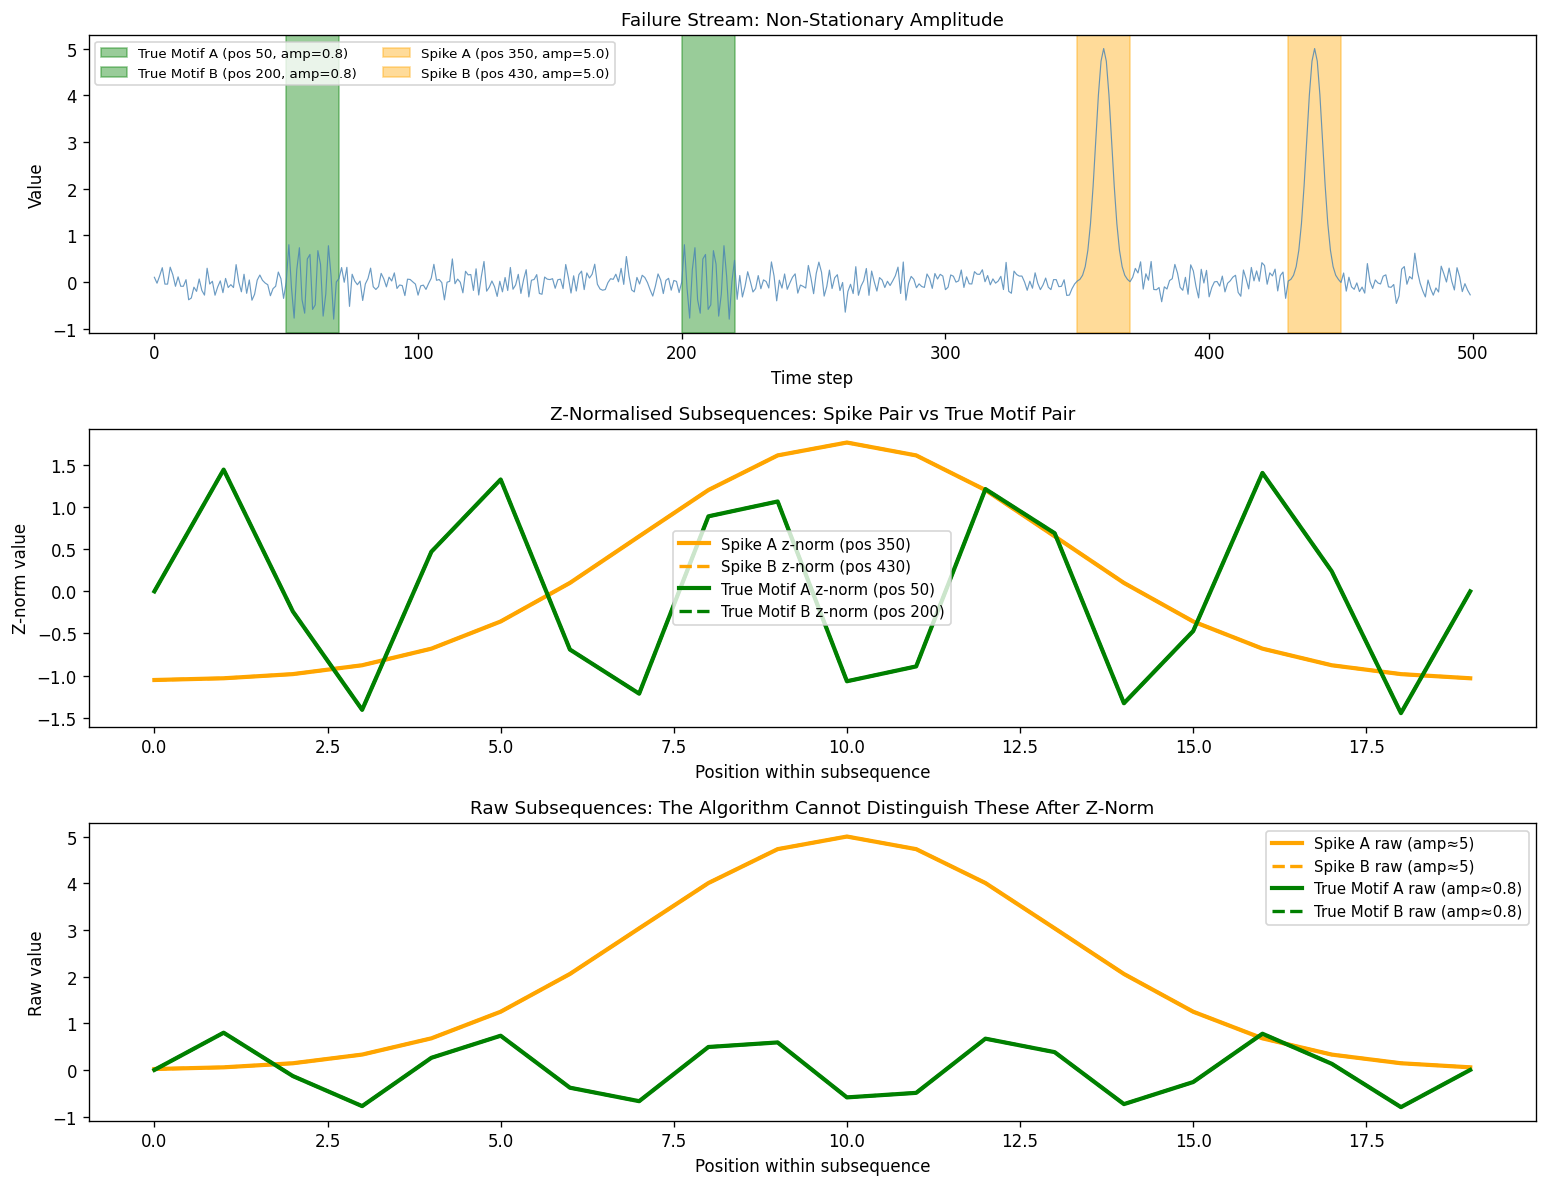

Plot saved: results/task_3_2_failure_mode.png


In [4]:
# ─── Visualisation: Failure mode demonstration ───────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 10), dpi=120)

# Top: full failure stream
axes[0].plot(failure_stream, color='steelblue', linewidth=0.7, alpha=0.8)
axes[0].axvspan(50,  70,  color='green',  alpha=0.4, label='True Motif A (pos 50, amp=0.8)')
axes[0].axvspan(200, 220, color='green',  alpha=0.4, label='True Motif B (pos 200, amp=0.8)')
axes[0].axvspan(350, 370, color='orange', alpha=0.4, label='Spike A (pos 350, amp=5.0)')
axes[0].axvspan(430, 450, color='orange', alpha=0.4, label='Spike B (pos 430, amp=5.0)')
axes[0].set_title('Failure Stream: Non-Stationary Amplitude', fontsize=11)
axes[0].set_xlabel('Time step'); axes[0].set_ylabel('Value'); axes[0].legend(fontsize=8, ncol=2)

# Middle: z-normed shapes compared
x = np.arange(m)
if z_spike1 is not None: axes[1].plot(x, z_spike1, 'orange', linewidth=2.5, label='Spike A z-norm (pos 350)')
if z_spike2 is not None: axes[1].plot(x, z_spike2, 'orange', linestyle='--', linewidth=2.0, label='Spike B z-norm (pos 430)')
if z_true1  is not None: axes[1].plot(x, z_true1,  'green',  linewidth=2.5, label='True Motif A z-norm (pos 50)')
if z_true2  is not None: axes[1].plot(x, z_true2,  'green',  linestyle='--', linewidth=2.0, label='True Motif B z-norm (pos 200)')
axes[1].set_title('Z-Normalised Subsequences: Spike Pair vs True Motif Pair', fontsize=11)
axes[1].set_xlabel('Position within subsequence'); axes[1].set_ylabel('Z-norm value'); axes[1].legend(fontsize=9)

# Bottom: raw shapes compared
raw_spike1 = failure_stream[350: 350+m]
raw_spike2 = failure_stream[430: 430+m]
raw_true1  = failure_stream[50:  50+m]
raw_true2  = failure_stream[200: 200+m]
axes[2].plot(x, raw_spike1, 'orange', linewidth=2.5, label='Spike A raw (amp≈5)')
axes[2].plot(x, raw_spike2, 'orange', linestyle='--', linewidth=2.0, label='Spike B raw (amp≈5)')
axes[2].plot(x, raw_true1,  'green',  linewidth=2.5, label='True Motif A raw (amp≈0.8)')
axes[2].plot(x, raw_true2,  'green',  linestyle='--', linewidth=2.0, label='True Motif B raw (amp≈0.8)')
axes[2].set_title('Raw Subsequences: The Algorithm Cannot Distinguish These After Z-Norm', fontsize=11)
axes[2].set_xlabel('Position within subsequence'); axes[2].set_ylabel('Raw value'); axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('results/task_3_2_failure_mode.png', dpi=120, bbox_inches='tight')
plt.show()
print("Plot saved: results/task_3_2_failure_mode.png")


## Why the Method Fails in This Scenario

The algorithm fails here because it relies on **Assumption 2** from Task 1.2: that z-normalised Euclidean distance faithfully represents meaningful structural similarity. In this non-stationary stream, z-normalisation makes a 5× amplitude Gaussian spike look identical to a 0.8× amplitude sine burst — both have zero mean and unit variance after normalisation. The method correctly identifies the closest pair in z-normalised space, but that pair is semantically meaningless: they are different phenomena (spikes vs. motifs) that happen to share a similar *shape* after normalisation flattens away amplitude information.

The failure connects directly to the design choice described in Section 2: the paper explicitly notes that the algorithm treats each z-normalised subsequence "as an independent object... unrelated to other objects/points." This independence means the original scale is lost permanently. In domains where *amplitude itself carries semantic information* — such as seismic monitoring (large vs. small tremors), financial data (large vs. small price moves), or biomedical signals (strong vs. weak neural spikes) — this design choice causes the algorithm to report spurious motifs.

The paper's own warning (Section 2: "if appropriate we can work with non-normalized data") acknowledges this limitation implicitly but does not provide an in-algorithm remedy for mixed-regime streams.

**Suggested modification:** Introduce a *regime-aware* version of the algorithm that clusters subsequences into amplitude bands before applying z-normalisation, so that motif candidates are only compared within the same amplitude regime. This would require O(w log w) pre-sorting overhead but would prevent cross-regime false motifs while preserving the z-norm invariance benefit for within-regime comparisons. No implementation is required.
